# This notebook is used to process trait score on December ses 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading extracted trait data

In [3]:
# data has been extracted from raw firebase files (see psyanim2_analysis for more detail)
# import raw trait data from csv
df_panas = pd.read_csv('./data_extraction/panas_dec_ses1.csv')
df_aq = pd.read_csv('./data_extraction/aq_dec_ses1.csv')
df_srs = pd.read_csv('./data_extraction/srs_dec_ses1.csv')
df_prim = pd.read_csv('./data_extraction/prim_dec_ses1.csv')

## Modifying trait scores from text to num

In [4]:
# panas 
df_panas_mod = pd.DataFrame()
df_panas_mod = df_panas.copy()
df_panas_mod.replace('Very slightly or not at all (1) ', 0, inplace=True)
df_panas_mod.replace('A little (2)', 1, inplace=True)
df_panas_mod.replace('Moderately (3)', 2, inplace=True)
df_panas_mod.replace('Quite a bit (4)', 3, inplace=True)
df_panas_mod.replace('Extremely (5)', 4, inplace=True)

# saving intermediate steps
#df_panas_mod.to_csv('./trait_analysis/panas_score_converted.csv', index = False)

In [5]:
# aq
df_aq_mod = pd.DataFrame()
df_aq_mod = df_aq.copy()
aq_resp = ["Definitely disagree", "Slightly disagree", "Slightly agree", "Definitely agree"]
df_aq_mod.replace('Definitely disagree', 0, inplace=True)
df_aq_mod.replace('Slightly disagree', 1, inplace=True)
df_aq_mod.replace('Slightly agree', 2, inplace=True)
df_aq_mod.replace('Definitely agree', 3, inplace=True)
df_aq_mod
# saving intermediate steps
df_aq_mod.to_csv('./trait_analysis/aq_score_converted.csv', index = False)

In [6]:
# srs: bc recollection of last question, the score conversion needed to process two different types of strings answers
df_srs_mod = pd.DataFrame()
df_srs_mod = df_srs.copy()
df_srs_mod.replace('Not True (1)', 0, inplace=True)
df_srs_mod.replace('Not true (1)', 0, inplace=True)
df_srs_mod.replace('Sometimes True (2)', 1, inplace=True)
df_srs_mod.replace('Sometimes true (2)', 1, inplace=True)
df_srs_mod.replace('Often True (3)', 2, inplace=True)
df_srs_mod.replace('Often true (3)', 2, inplace=True)
df_srs_mod.replace('Almost always True (4)', 3, inplace=True)
df_srs_mod.replace('Almost always true (4)', 3, inplace=True)

# saving intermediate steps
df_srs_mod.to_csv('./trait_analysis/srs_score_converted.csv', index = False)

In [7]:
# Primal
df_prim_mod = pd.DataFrame()
df_prim_mod = df_prim.copy()
df_prim_mod.replace('Strongly disagree', 0, inplace=True)
df_prim_mod.replace('Disagree', 1, inplace=True)
df_prim_mod.replace('Slightly disagree', 2, inplace=True)
df_prim_mod.replace('Slightly agree', 3, inplace=True)
df_prim_mod.replace('Agree', 4, inplace=True)
df_prim_mod.replace('Strongly agree', 5, inplace=True)

# saving intermediate steps
df_prim_mod.to_csv('./trait_analysis/prim_score_converted.csv', index = False)

## Dealing with reverse coding & subsales

In [8]:
# PANAS: adding the different spectrums in the survey [Positive & Negative]
pos = [1, 3, 6, 10, 11, 13, 15, 17, 18, 20]
neg = [2, 5, 7, 8, 9, 12, 14, 16, 19, 21]
df_panas_rev = pd.DataFrame()
df_panas_rev = df_panas_mod.copy()
df_panas_rev['Positive'] = df_panas_rev.iloc[:, pos].sum(axis = 1)
df_panas_rev['Negative'] = df_panas_rev.iloc[:, neg].sum(axis = 1)
df_panas_rev
# saving intermediate steps
# df_panas_rev.to_csv('./trait_analysis/panas_subscale.csv', index = False)

,Participant ID,1_PANAS_qn0,1_PANAS_qn1,1_PANAS_qn2,1_PANAS_qn3,1_PANAS_qn4,1_PANAS_qn5,1_PANAS_qn6,1_PANAS_qn7,1_PANAS_qn8,...,2_PANAS_qn13,2_PANAS_qn14,2_PANAS_qn15,2_PANAS_qn16,2_PANAS_qn17,2_PANAS_qn18,2_PANAS_qn19,2_PANAS_qn20,Positive,Negative
0,1,3,2.0,1.0,4,1,0.0,1.0,0.0,1,...,0.0,2.0,3.0,2.0,1.0,1,1,1,13.0,11.0
1,2,4,0.0,3.0,4,0,2.0,0.0,0.0,0,...,0.0,4.0,1.0,3.0,4.0,0,3,0,33.0,2.0
2,3,3,1.0,4.0,4,1,3.0,1.0,1.0,0,...,1.0,2.0,2.0,3.0,2.0,4,3,1,28.0,15.0
3,4,3,1.0,0.0,4,1,2.0,1.0,1.0,0,...,0.0,1.0,1.0,2.0,3.0,1,2,0,19.0,7.0
4,5,0,1.0,0.0,4,1,0.0,0.0,1.0,0,...,1.0,1.0,2.0,0.0,0.0,1,0,1,3.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,344,2,3.0,2.0,4,3,2.0,1.0,4.0,3,...,3.0,2.0,3.0,3.0,3.0,2,2,4,23.0,29.0
344,345,3,0.0,1.0,4,0,1.0,0.0,0.0,0,...,0.0,2.0,0.0,2.0,3.0,0,0,0,20.0,1.0
345,346,2,1.0,2.0,4,2,1.0,1.0,1.0,2,...,1.0,2.0,1.0,1.0,1.0,0,2,1,15.0,13.0
346,347,4,0.0,3.0,4,0,3.0,0.0,0.0,0,...,0.0,3.0,0.0,3.0,3.0,0,4,0,34.0,0.0


In [9]:
# AQ: reverse coding + adding subscales 
reverse_aq = [1, 3, 8, 10, 11, 14, 15, 17, 24, 25, 27, 28, 29, 30, 31, 32, 34, 37, 38, 39, 41, 45, 48, 49, 50, 51]
df_aq_rev = pd.DataFrame()
df_aq_rev = df_aq_mod.copy()
def reverse_code(value, max_value):
    return max_value - value

# Apply the reverse_code function to the specified columns
for col_index in reverse_aq:
    max_value = 3
    df_aq_rev.iloc[:, col_index] = df_aq_rev.iloc[:, col_index].apply(reverse_code, args=(max_value,))


social_skill = [1, 11, 13, 15, 22, 37, 45, 46, 48, 49]
attn_switch = [2, 4, 10, 16, 25, 32, 34, 38, 44, 47]
img = [3, 8, 14, 20, 21, 24, 41, 42, 43, 51]
attn_to_det = [5, 6, 9, 12, 19, 23, 28, 29, 30, 50]
comm = [7, 17, 18, 26, 27, 31, 33, 35, 39, 40]
df_aq_rev['social skill'] = df_aq_rev.iloc[:, social_skill].sum(axis = 1)
df_aq_rev['attention switching'] = df_aq_rev.iloc[:, attn_switch].sum(axis = 1)
df_aq_rev['imagination'] = df_aq_rev.iloc[:, img].sum(axis = 1)
df_aq_rev['attention to detail'] = df_aq_rev.iloc[:, attn_to_det].sum(axis = 1)
df_aq_rev['communication'] = df_aq_rev.iloc[:, comm].sum(axis = 1)
df_aq_rev
df_aq_rev.to_csv('./trait_analysis/aq_subscale.csv', index = False)

In [10]:
# SRS: reverse coding + adding subscales
df_srs_trait = pd.read_excel('SRS-2.xlsx')
qns_type =  df_srs_trait['Trait dimension'].values

MOT  = np.where(qns_type == 'MOT')[0] + 2
AWR = np.where(qns_type == 'AWR')[0] + 2
RRB = np.where(qns_type == 'RRB')[0] + 2
COG  = np.where(qns_type == 'COG')[0] + 2
COM  = np.where(qns_type == 'COM')[0] + 2
SCI  = np.where((qns_type == 'COM') | (qns_type == 'COG') | (qns_type == 'AWR') | (qns_type == 'MOT'))[0] + 2

# print(len(MOT), len(AWR), len(RRB), len(COG), len(COM), len(SCI))
# print(MOT, AWR,RRB, COG, COM, SCI)
reversed_srs = np.where(df_srs_trait['Scoring type']=='Reversed')[0] + 2
# print(reversed_srs)

df_srs_rev = pd.DataFrame()
df_srs_rev = df_srs_mod.copy()

for col_index in reversed_srs:
    max_value = 3
    df_srs_rev.iloc[:, col_index] = df_srs_rev.iloc[:, col_index].apply(reverse_code, args=(max_value,))
    
df_srs_rev['MOT'] = df_srs_rev.iloc[:, MOT].sum(axis = 1)
df_srs_rev['AWR'] = df_srs_rev.iloc[:, AWR].sum(axis = 1)
df_srs_rev['RRB'] = df_srs_rev.iloc[:, RRB].sum(axis = 1)
df_srs_rev['COG'] = df_srs_rev.iloc[:, COG].sum(axis = 1)
df_srs_rev['COM'] = df_srs_rev.iloc[:, COM].sum(axis = 1)
df_srs_rev['SCI'] = df_srs_rev.iloc[:, SCI].sum(axis = 1)
df_srs_rev
df_srs_rev.to_csv('./trait_analysis/srs_subscale.csv', index = False)

In [11]:
# Primals: reverse coding + adding subscale
reverse_prim = [5, 6, 9, 10, 11, 12, 13]

df_prim_rev= pd.DataFrame()
df_prim_rev = df_prim_mod.copy()

for col_index in reverse_prim:
    max_value = 5
    df_prim_rev.iloc[:, col_index] = df_prim_rev.iloc[:, col_index].apply(reverse_code, args=(max_value,))
df_prim_rev

enti = [1, 5, 6, 7, 8, 9, 19]
alive = [2, 4, 12, 14, 16]
safe = [3, 10, 11, 13, 15, 18]
df_prim_rev['Enticing'] = df_prim_rev.iloc[:, enti].sum(axis = 1)
df_prim_rev['Alive'] = df_prim_rev.iloc[:, alive].sum(axis = 1)
df_prim_rev['Safe'] = df_prim_rev.iloc[:, safe].sum(axis = 1)
df_prim_rev
df_prim_rev.to_csv('./trait_analysis/prim_subscale.csv', index = False)

## Dealing with missing responses

In [12]:
# nan mean, reweighed sum, missResp for each subscale
# panas
df_panas_wed = pd.DataFrame()
df_panas_wed = df_panas_rev.copy()
df_panas_wed['Positive_nanMean'] = df_panas_wed.iloc[:, pos].mean(axis=1, skipna=True)
df_panas_wed['Negative_nanMean'] = df_panas_wed.iloc[:, neg].mean(axis=1, skipna=True)
df_panas_wed['Positive_numMissResp'] = df_panas_wed.iloc[:, pos].isna().sum(axis = 1)
df_panas_wed['Negative_numMissResp'] = df_panas_wed.iloc[:, neg].isna().sum(axis = 1)

df_panas_wed['Positive_reweigh'] = df_panas_wed['Positive'] * len(pos)/(len(pos)-df_panas_wed['Positive_numMissResp'])
df_panas_wed['Negative_reweigh'] = df_panas_wed['Negative'] * len(neg)/(len(neg)-df_panas_wed['Negative_numMissResp'])

df_panas_wed['Total_numMissResp'] = df_panas_wed.isna().sum(axis=1)
df_panas_wed
df_panas_wed.to_csv('./trait_analysis/panas_missResp.csv', index = False)

In [13]:
# aq
df_aq_wed = pd.DataFrame()
df_aq_wed = df_aq_rev.copy()

# social_skill = [1, 11, 13, 15, 22, 37, 45, 46, 48, 49]
# attn_switch = [2, 4, 10, 16, 25, 32, 34, 38, 44, 47]
# img = [3, 8, 14, 20, 21, 24, 41, 42, 43, 51]
# attn_to_det = [5, 6, 9, 12, 19, 23, 28, 29, 30, 50]
# comm = [7, 17, 18, 26, 27, 31, 33, 35, 39, 40]

df_aq_wed['social_skill_nanMean'] = df_aq_wed.iloc[:, social_skill].mean(axis=1, skipna=True)
df_aq_wed['attn_switch_nanMean'] = df_aq_wed.iloc[:, attn_switch].mean(axis=1, skipna=True)
df_aq_wed['img_nanMean'] = df_aq_wed.iloc[:, img].mean(axis=1, skipna=True)
df_aq_wed['attn_to_det_nanMean'] = df_aq_wed.iloc[:, attn_to_det].mean(axis=1, skipna=True)
df_aq_wed['comm_nanMean'] = df_aq_wed.iloc[:, comm].mean(axis=1, skipna=True)

df_aq_wed['social_skill_numMissResp'] = df_aq_wed.iloc[:, social_skill].isna().sum(axis = 1)
df_aq_wed['attn_switch_numMissResp'] = df_aq_wed.iloc[:, attn_switch].isna().sum(axis = 1)
df_aq_wed['img_numMissResp'] = df_aq_wed.iloc[:, img].isna().sum(axis = 1)
df_aq_wed['attn_to_det_numMissResp'] = df_aq_wed.iloc[:, attn_to_det].isna().sum(axis = 1)
df_aq_wed['comm_numMissResp'] = df_aq_wed.iloc[:, comm].isna().sum(axis = 1)

df_aq_wed['social_skill_reweigh'] = df_aq_wed['social skill'] * len(social_skill)/(len(social_skill)-df_aq_wed['social_skill_numMissResp'])
df_aq_wed['attn_switch_reweigh'] = df_aq_wed['attention switching'] * len(attn_switch)/(len(attn_switch)-df_aq_wed['attn_switch_numMissResp'])
df_aq_wed['img_reweigh'] = df_aq_wed['imagination'] * len(img)/(len(img)-df_aq_wed['img_numMissResp'])
df_aq_wed['attn_to_det_reweigh'] = df_aq_wed['attention to detail'] * len(attn_to_det)/(len(attn_to_det)-df_aq_wed['attn_to_det_numMissResp'])
df_aq_wed['comm_reweigh'] = df_aq_wed['communication'] * len(comm)/(len(comm)-df_aq_wed['comm_numMissResp'])


df_aq_wed['Total_numMissResp'] = df_aq_wed.isna().sum(axis=1)
df_aq_wed
df_aq_wed.to_csv('./trait_analysis/aq_missResp.csv', index = False)

In [14]:
df_srs_wed = pd.DataFrame()
df_srs_wed = df_srs_rev.copy()

MOT  = np.where(qns_type == 'MOT')[0] + 2
AWR = np.where(qns_type == 'AWR')[0] + 2
RRB = np.where(qns_type == 'RRB')[0] + 2
COG  = np.where(qns_type == 'COG')[0] + 2
COM  = np.where(qns_type == 'COM')[0] + 2
SCI  = np.where((qns_type == 'COM') | (qns_type == 'COG') | (qns_type == 'AWR') | (qns_type == 'MOT'))[0] + 2
print(len(MOT), len(AWR), len(RRB), len(COG), len(COM), len(SCI))

df_srs_wed['MOT_nanMean'] = df_srs_wed.iloc[:, MOT].mean(axis=1, skipna=True)
df_srs_wed['AWR_nanMean'] = df_srs_wed.iloc[:, AWR].mean(axis=1, skipna=True)
df_srs_wed['RRB_nanMean'] = df_srs_wed.iloc[:, RRB].mean(axis=1, skipna=True)
df_srs_wed['COG_nanMean'] = df_srs_wed.iloc[:, COG].mean(axis=1, skipna=True)
df_srs_wed['COM_nanMean'] = df_srs_wed.iloc[:, COM].mean(axis=1, skipna=True)
df_srs_wed['SCI_nanMean'] = df_srs_wed.iloc[:, SCI].mean(axis=1, skipna=True)

df_srs_wed['MOT_numMissResp'] = df_srs_wed.iloc[:, MOT].isna().sum(axis = 1)
df_srs_wed['AWR_numMissResp'] = df_srs_wed.iloc[:, AWR].isna().sum(axis = 1)
df_srs_wed['RRB_numMissResp'] = df_srs_wed.iloc[:, RRB].isna().sum(axis = 1)
df_srs_wed['COG_numMissResp'] = df_srs_wed.iloc[:, COG].isna().sum(axis = 1)
df_srs_wed['COM_numMissResp'] = df_srs_wed.iloc[:, COM].isna().sum(axis = 1)
df_srs_wed['SCI_numMissResp'] = df_srs_wed.iloc[:, SCI].isna().sum(axis = 1)

df_srs_wed['MOT_reweigh'] = df_srs_wed['MOT'] * len(MOT)/(len(MOT)-df_srs_wed['MOT_numMissResp'])
df_srs_wed['AWR_reweigh'] = df_srs_wed['AWR'] * len(AWR)/(len(AWR)-df_srs_wed['AWR_numMissResp'])
df_srs_wed['RRB_reweigh'] = df_srs_wed['RRB'] * len(RRB)/(len(RRB)-df_srs_wed['RRB_numMissResp'])
df_srs_wed['COG_reweigh'] = df_srs_wed['COG'] * len(COG)/(len(COG)-df_srs_wed['COG_numMissResp'])
df_srs_wed['COM_reweigh'] = df_srs_wed['COM'] * len(COM)/(len(COM)-df_srs_wed['COM_numMissResp'])
df_srs_wed['SCI_reweigh'] = df_srs_wed['SCI'] * len(SCI)/(len(SCI)-df_srs_wed['SCI_numMissResp'])


df_srs_wed['Total_numMissResp'] = df_srs_wed.isna().sum(axis=1)
df_srs_wed
df_srs_wed.to_csv('./trait_analysis/srs_missResp.csv', index = False)

11 8 12 12 22 53


In [15]:
# Primals
enti = [1, 5, 6, 7, 8, 9, 19]
alive = [2, 4, 12, 14, 16]
safe = [3, 10, 11, 13, 15, 18]

df_prim_wed = pd.DataFrame()
df_prim_wed = df_prim_rev.copy()
df_prim_wed['enti_nanMean'] = df_prim_wed.iloc[:, enti].mean(axis=1, skipna=True)
df_prim_wed['alive_nanMean'] = df_prim_wed.iloc[:, alive].mean(axis=1, skipna=True)
df_prim_wed['safe_nanMean'] = df_prim_wed.iloc[:, safe].mean(axis=1, skipna=True)

df_prim_wed['enti_numMissResp'] = df_prim_wed.iloc[:, enti].isna().sum(axis = 1)
df_prim_wed['alive_numMissResp'] = df_prim_wed.iloc[:, alive].isna().sum(axis = 1)
df_prim_wed['safe_numMissResp'] = df_prim_wed.iloc[:, safe].isna().sum(axis = 1)

df_prim_wed['enti_reweigh'] = df_prim_wed['Enticing'] * len(enti)/(len(enti)-df_prim_wed['enti_numMissResp'])
df_prim_wed['alive_reweigh'] = df_prim_wed['Alive'] * len(alive)/(len(alive)-df_prim_wed['alive_numMissResp'])
df_prim_wed['safe_reweigh'] = df_prim_wed['Safe'] * len(safe)/(len(safe)-df_prim_wed['safe_numMissResp'])

df_prim_wed['Total_numMissResp'] = df_prim_wed.isna().sum(axis=1)
df_prim_wed
df_prim_wed.to_csv('./trait_analysis/prim_missResp.csv', index = False)

## Graphing distribution of the traits

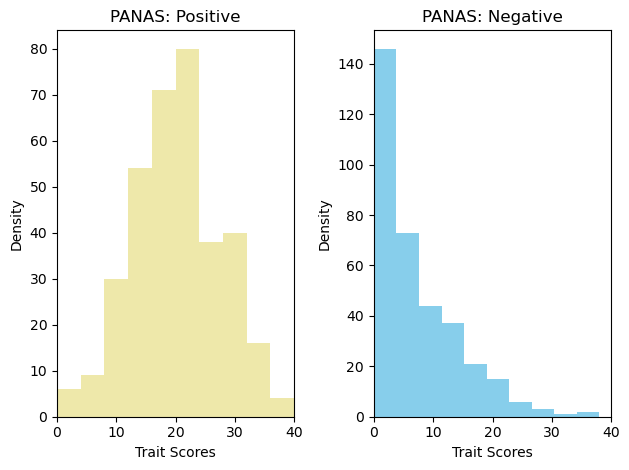

In [16]:
fig, ax = plt.subplots(1,2)
ax[0].hist(x=df_panas_wed['Positive'], color = 'palegoldenrod')
ax[0].set_title('PANAS: Positive') 
ax[0].set_xlim(0, 40)
ax[0].set_xlabel('Trait Scores')
ax[0].set_ylabel('Density')

ax[1].hist(x=df_panas_wed['Negative'], color = 'skyblue')
ax[1].set_title('PANAS: Negative') 
ax[1].set_xlim(0, 40)
ax[1].set_xlabel('Trait Scores')
ax[1].set_ylabel('Density')
plt.savefig('./trait_analysis/panas_dist.png')
plt.tight_layout()
plt.show()


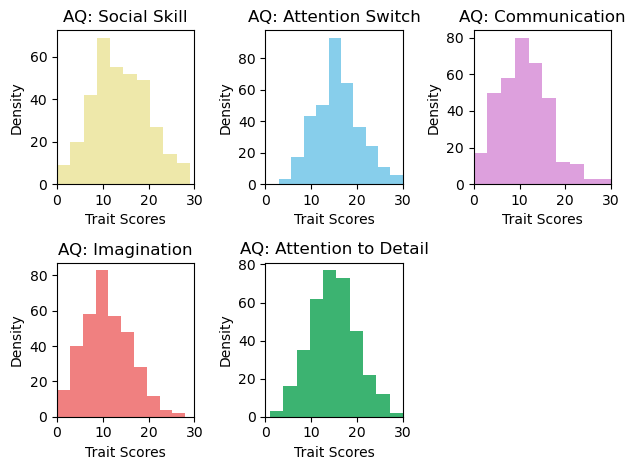

In [17]:
fig, ax = plt.subplots(2, 3)
ax[0, 0].hist(x=df_aq_wed['social_skill_reweigh'], color = 'palegoldenrod')
ax[0, 0].set_title('AQ: Social Skill') 
ax[0, 0].set_xlim(0, 30)
ax[0, 0].set_xlabel('Trait Scores')
ax[0, 0].set_ylabel('Density')

ax[0,1].hist(x=df_aq_wed['attn_switch_reweigh'], color = 'skyblue')
ax[0,1].set_title('AQ: Attention Switch') 
ax[0,1].set_xlim(0, 30)
ax[0,1].set_xlabel('Trait Scores')
ax[0,1].set_ylabel('Density')

ax[1,0].hist(x=df_aq_wed['img_reweigh'], color = 'lightcoral')
ax[1,0].set_title('AQ: Imagination') 
ax[1,0].set_xlim(0, 30)
ax[1,0].set_xlabel('Trait Scores')
ax[1,0].set_ylabel('Density')

ax[1,1].hist(x=df_aq_wed['attn_to_det_reweigh'], color = 'mediumseagreen')
ax[1,1].set_title('AQ: Attention to Detail') 
ax[1,1].set_xlim(0, 30)
ax[1,1].set_xlabel('Trait Scores')
ax[1,1].set_ylabel('Density')

ax[0,2].hist(x=df_aq_wed['comm_reweigh'], color = 'plum')
ax[0,2].set_title('AQ: Communication') 
ax[0,2].set_xlim(0, 30)
ax[0,2].set_xlabel('Trait Scores')
ax[0,2].set_ylabel('Density')

ax[-1, -1].axis('off')
plt.tight_layout()

plt.savefig('./trait_analysis/aq_dist.png')
plt.show()

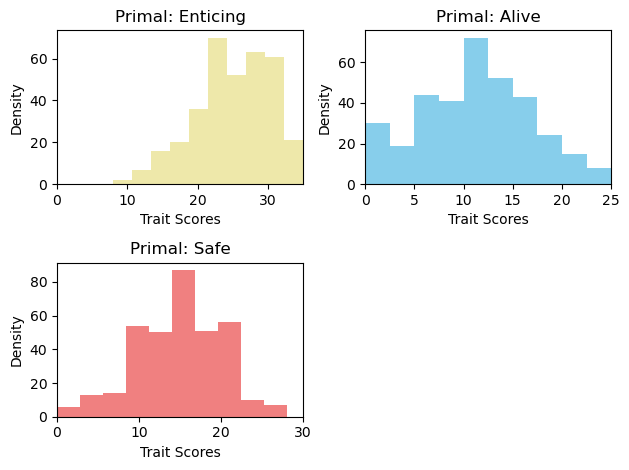

In [18]:
fig, ax = plt.subplots(2, 2)
ax[0, 0].hist(x=df_prim_wed['enti_reweigh'], color = 'palegoldenrod')
ax[0, 0].set_title('Primal: Enticing') 
ax[0, 0].set_xlim(0, 35)
ax[0, 0].set_xlabel('Trait Scores')
ax[0, 0].set_ylabel('Density')

ax[0,1].hist(x=df_prim_wed['alive_reweigh'], color = 'skyblue')
ax[0,1].set_title('Primal: Alive') 
ax[0,1].set_xlim(0, 25)
ax[0,1].set_xlabel('Trait Scores')
ax[0,1].set_ylabel('Density')

ax[1,0].hist(x=df_prim_wed['safe_reweigh'], color = 'lightcoral')
ax[1,0].set_title('Primal: Safe') 
ax[1,0].set_xlim(0, 30)
ax[1,0].set_xlabel('Trait Scores')
ax[1,0].set_ylabel('Density')

ax[-1, -1].axis('off')
plt.tight_layout()

plt.savefig('./trait_analysis/prim_dist.png')
plt.show()

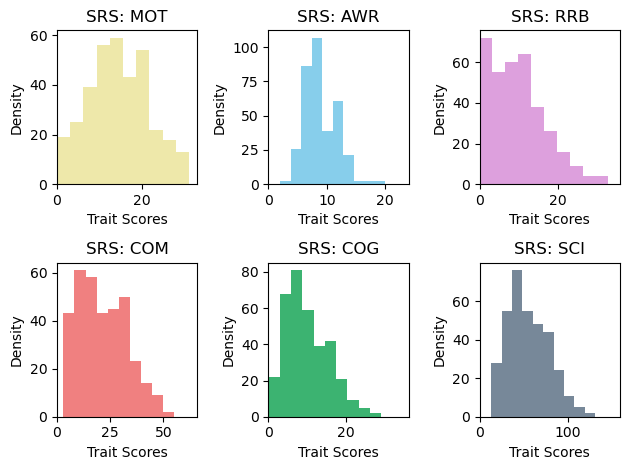

In [19]:
fig, ax = plt.subplots(2, 3)
ax[0, 0].hist(x=df_srs_wed['MOT_reweigh'], color = 'palegoldenrod')
ax[0, 0].set_title('SRS: MOT') 
ax[0, 0].set_xlim(0, 33)
ax[0, 0].set_xlabel('Trait Scores')
ax[0, 0].set_ylabel('Density')

ax[0,1].hist(x=df_srs_wed['AWR_reweigh'], color = 'skyblue')
ax[0,1].set_title('SRS: AWR') 
ax[0,1].set_xlim(0, 24)
ax[0,1].set_xlabel('Trait Scores')
ax[0,1].set_ylabel('Density')

ax[0,2].hist(x=df_srs_wed['RRB_reweigh'], color = 'plum')
ax[0,2].set_title('SRS: RRB') 
ax[0,2].set_xlim(0, 36)
ax[0,2].set_xlabel('Trait Scores')
ax[0,2].set_ylabel('Density')

ax[1,0].hist(x=df_srs_wed['COM_reweigh'], color = 'lightcoral')
ax[1,0].set_title('SRS: COM') 
ax[1,0].set_xlim(0, 66)
ax[1,0].set_xlabel('Trait Scores')
ax[1,0].set_ylabel('Density')

ax[1,1].hist(x=df_srs_wed['COG_reweigh'], color = 'mediumseagreen')
ax[1,1].set_title('SRS: COG') 
ax[1,1].set_xlim(0, 36)
ax[1,1].set_xlabel('Trait Scores')
ax[1,1].set_ylabel('Density')

ax[1,2].hist(x=df_srs_wed['SCI_reweigh'], color = 'lightslategray')
ax[1,2].set_title('SRS: SCI') 
ax[1,2].set_xlim(0, 159)
ax[1,2].set_xlabel('Trait Scores')
ax[1,2].set_ylabel('Density')


plt.tight_layout()

plt.savefig('./trait_analysis/srs_dist.png')
plt.show()

## Correlation between aq and srs subscales

In [20]:
aq_sub_scales = df_aq_wed[['social_skill_reweigh', 'attn_switch_reweigh', 'img_reweigh', 'attn_to_det_reweigh', 'comm_reweigh']]
srs_sub_scales = df_srs_wed[['MOT_reweigh', 'AWR_reweigh', 'RRB_reweigh', 'COM_reweigh', 'COG_reweigh', 'SCI_reweigh']]

# Initialize correlation matrix
correlation_matrix = pd.DataFrame(index=aq_sub_scales.columns, columns=srs_sub_scales.columns)

# Compute correlations
for aq_sub_scale in aq_sub_scales.columns:
    for srs_sub_scale in srs_sub_scales.columns:
        correlation = np.corrcoef(aq_sub_scales[aq_sub_scale], srs_sub_scales[srs_sub_scale])[0, 1]
        correlation_matrix.loc[aq_sub_scale, srs_sub_scale] = correlation

# Fill diagonal with 1s
np.fill_diagonal(correlation_matrix.values, 1)

# Display correlation matrix
print(correlation_matrix)

                     MOT_reweigh AWR_reweigh RRB_reweigh COM_reweigh  \
social_skill_reweigh           1         NaN         NaN         NaN   
attn_switch_reweigh          NaN           1         NaN         NaN   
img_reweigh                  NaN         NaN           1         NaN   
attn_to_det_reweigh          NaN         NaN         NaN           1   
comm_reweigh                 NaN         NaN         NaN         NaN   

                     COG_reweigh SCI_reweigh  
social_skill_reweigh         NaN         NaN  
attn_switch_reweigh          NaN         NaN  
img_reweigh                  NaN         NaN  
attn_to_det_reweigh          NaN         NaN  
comm_reweigh                   1         NaN  


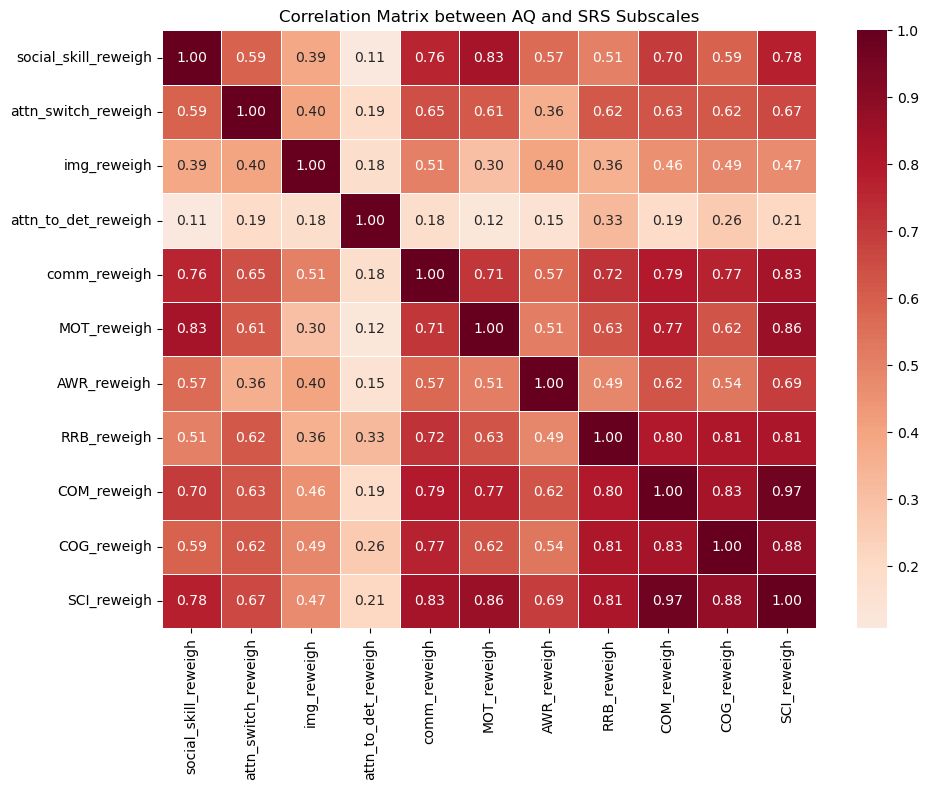

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
# Assuming df_aq and df_srs are already defined
aq_sub_scales = df_aq_wed[['social_skill_reweigh', 'attn_switch_reweigh', 'img_reweigh', 'attn_to_det_reweigh', 'comm_reweigh']]
srs_sub_scales = df_srs_wed[['MOT_reweigh', 'AWR_reweigh', 'RRB_reweigh', 'COM_reweigh', 'COG_reweigh', 'SCI_reweigh']]

# Concatenate the two dataframes
combined_df = pd.concat([aq_sub_scales, srs_sub_scales], axis=1)

# Compute correlation matrix
corr_matrix = combined_df.corr()
p_values = combined_df.corr(method=lambda x, y: pearsonr(x, y)[1])
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidth=.5)
plt.title('Correlation Matrix between AQ and SRS Subscales')
plt.tight_layout()
plt.savefig('./trait_analysis/aq_srs_matrix.png')

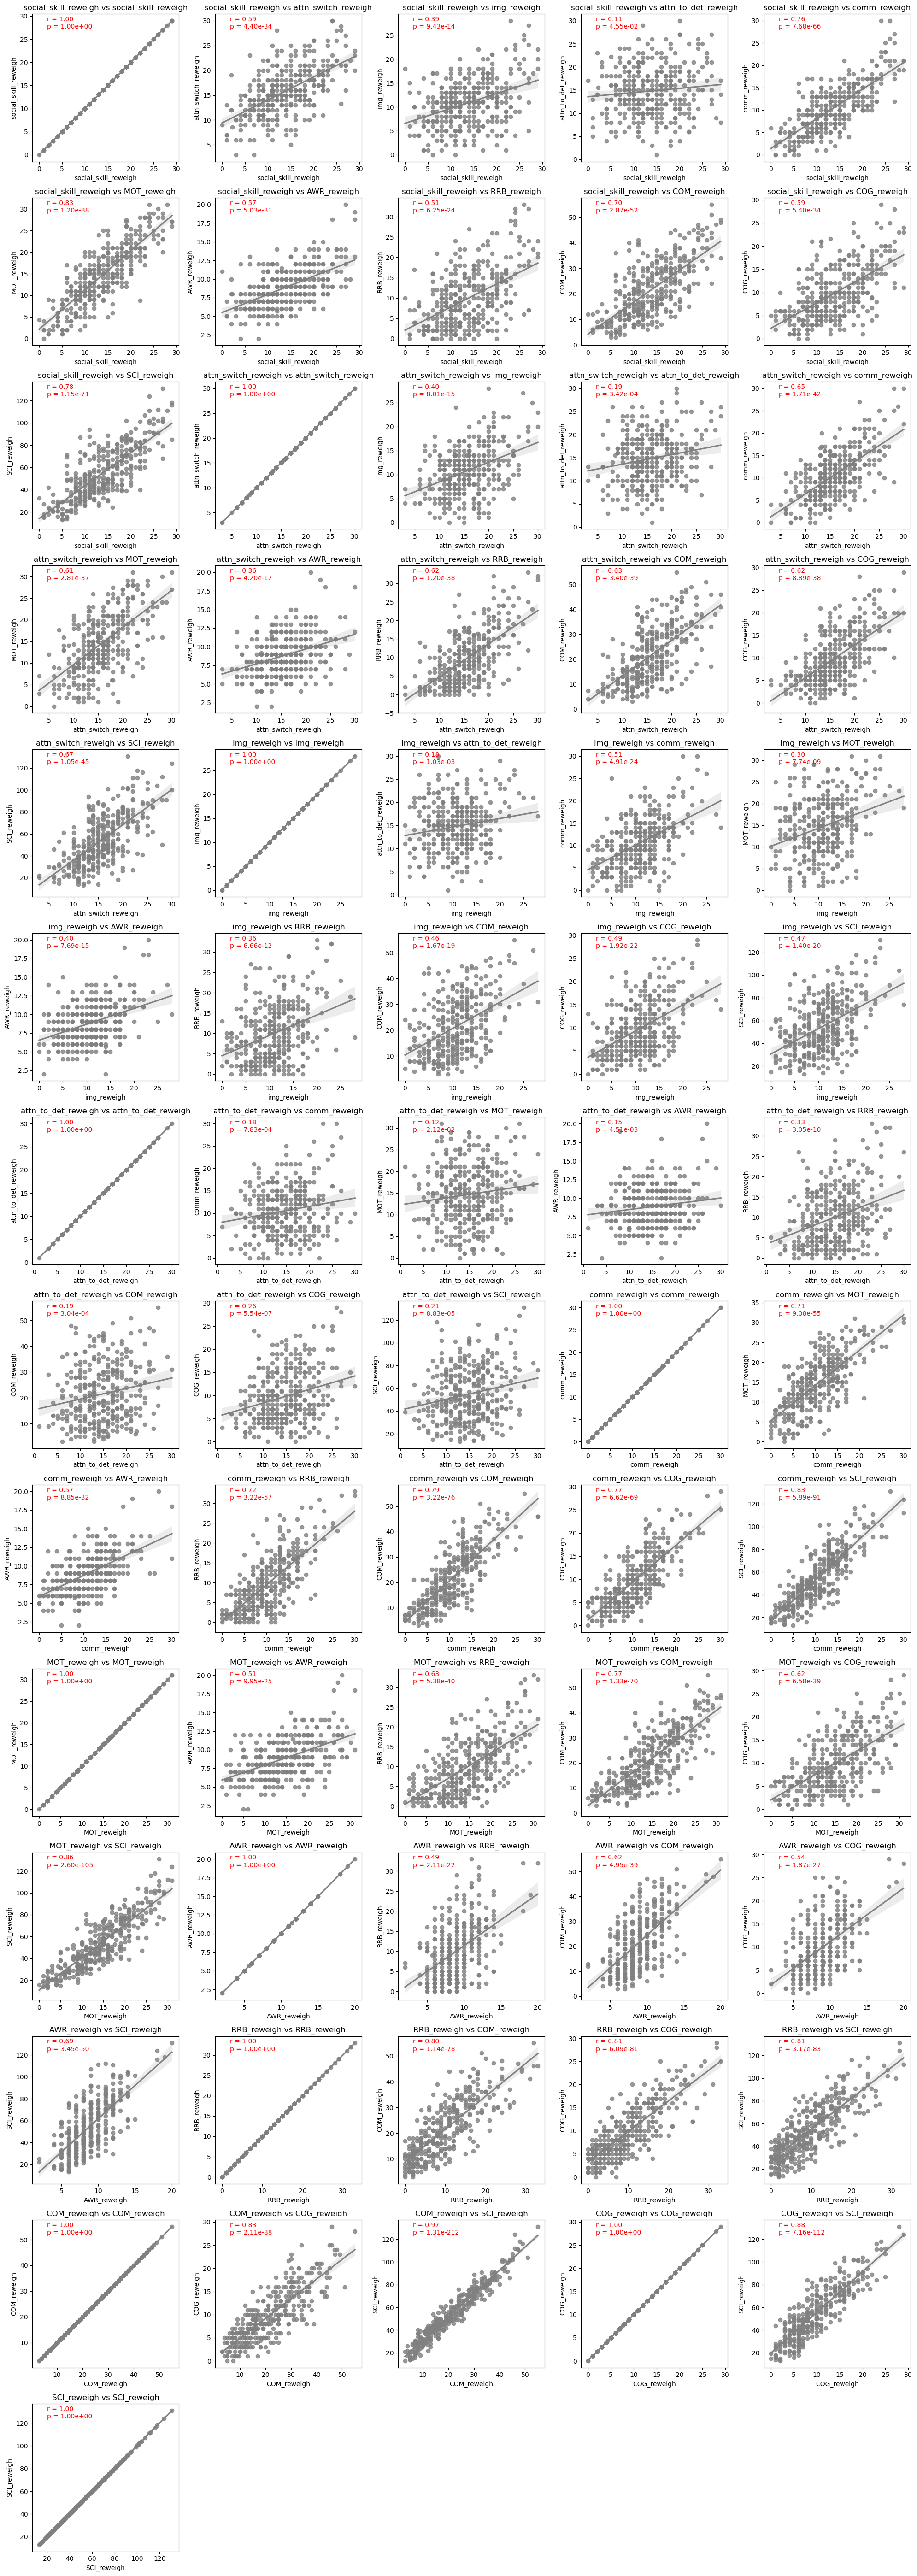

In [22]:
non_zero_corr_indices = np.where(~np.tri(*corr_matrix.values.shape, k=-1, dtype=bool))

# Set up the figure and axes for subplots
num_subplots = len(non_zero_corr_indices[0])
num_cols = 5  # Adjust the number of columns
num_rows = int(np.ceil(num_subplots / num_cols))
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, num_rows*4))

# Iterate over the non-zero correlations and plot the scatter plot with regression line
for i, (row_idx, col_idx) in enumerate(zip(*non_zero_corr_indices)):
    ax = axes[i // num_cols, i % num_cols] if num_rows > 1 else axes[i % num_cols]
    
    # Plot scatter plot with regression line (gray)
    sns.regplot(x=corr_matrix.index[row_idx], y=corr_matrix.columns[col_idx], data=combined_df, ax=ax, color='gray')
    
    # Add correlation coefficient (r) and p-value to the plot
    r = corr_matrix.iloc[row_idx, col_idx]
    p_value = p_values.iloc[row_idx, col_idx]
    text_color = 'red' if r > 0 else 'blue'  # Set text color based on correlation sign
    ax.text(0.1, 0.9, f'r = {r:.2f}\np = {p_value:.2e}', transform=ax.transAxes, fontsize=10, color=text_color)
    ax.set_title(f'{corr_matrix.index[row_idx]} vs {corr_matrix.columns[col_idx]}')

# Remove empty subplots
for i in range(num_subplots, num_rows * num_cols):
    fig.delaxes(axes.flatten()[i])

# Adjust layout
plt.subplots_adjust(left=0.05,
                        bottom=0.1, 
                        right=.98, 
                        top=.85, 
                        wspace=0.2, 
                        hspace=.15)
plt.tight_layout()
plt.savefig('./trait_analysis/aq_srs_rval.png')